In [7]:
import numpy as np
import matplotlib.pyplot as plt

X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_or = np.array([0, 1, 1, 1])

In [8]:
class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors_per_epoch = []
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                linear_output = np.dot(xi, self.weights) + self.bias
                y_pred = 1 if linear_output >= 0 else 0
                update = self.lr * (target - y_pred)
                self.weights += update * xi
                self.bias += update
                errors += int(update != 0)
            self.errors_per_epoch.append(errors)

In [9]:
p_or = Perceptron(learning_rate=0.1, epochs=20)
p_or.fit(X_or, y_or)

print("Weights:", p_or.weights)
print("Bias:", p_or.bias)
print("Predictions:", p_or.predict(X_or))

Weights: [0.1 0.1]
Bias: -0.1
Predictions: [0 1 1 1]


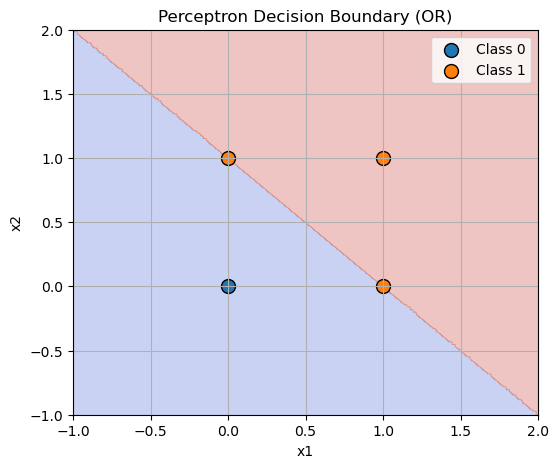

In [10]:
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

    for label in np.unique(y):
        pts = X[y == label]
        plt.scatter(pts[:, 0], pts[:, 1],
                    s=100, edgecolor='black',
                    label=f"Class {label}")

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_decision_boundary(X_or, y_or, p_or, "Perceptron Decision Boundary (OR)")

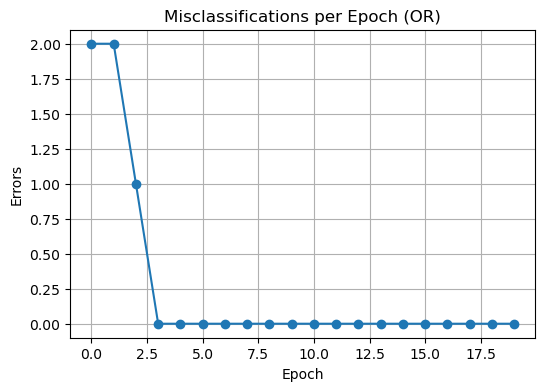

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(p_or.errors_per_epoch, marker='o')
plt.title("Misclassifications per Epoch (OR)")
plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.grid(True)
plt.show()

MLP

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step


In [3]:
gray_scale = 255

x_train = x_train.astype('float32') / gray_scale
x_test = x_test.astype('float32') / gray_scale

print("Feature matrix (x_train):", x_train.shape)
print("Target matrix (y_train):", y_train.shape)
print("Feature matrix (x_test):", x_test.shape)
print("Target matrix (y_test):", y_test.shape)

Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_train): (60000,)
Feature matrix (x_test): (10000, 28, 28)
Target matrix (y_test): (10000,)


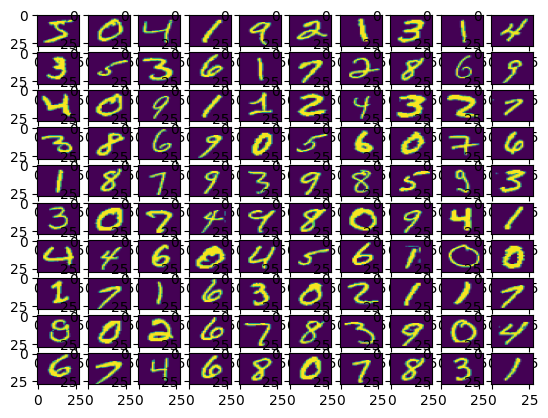

In [4]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto')
        k += 1
plt.show()

In [5]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='sigmoid'),  
    Dense(128, activation='sigmoid'), 
    Dense(10, activation='softmax'),  
])

c:\Users\krish\OneDrive\Desktop\week4\tf_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
mod = model.fit(x_train, y_train, epochs=10, 
          batch_size=2000, 
          validation_split=0.2)
          
print(mod)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.4126 - loss: 2.1369 - val_accuracy: 0.6137 - val_loss: 1.8048
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6946 - loss: 1.4906 - val_accuracy: 0.7713 - val_loss: 1.1509
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7976 - loss: 0.9751 - val_accuracy: 0.8481 - val_loss: 0.7737
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8512 - loss: 0.6950 - val_accuracy: 0.8783 - val_loss: 0.5701
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8781 - loss: 0.5362 - val_accuracy: 0.8921 - val_loss: 0.4546
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8922 - loss: 0.4432 - val_accuracy: 0.9050 - val_loss: 0.3869
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9011 - loss: 0.3863 - val_accuracy: 0.9104 - val_loss: 0.3454
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9076 - loss: 0.3486 - val_accuracy: 0.9137 - v

In [8]:
results = model.evaluate(x_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [0.28380170464515686, 0.9211000204086304]


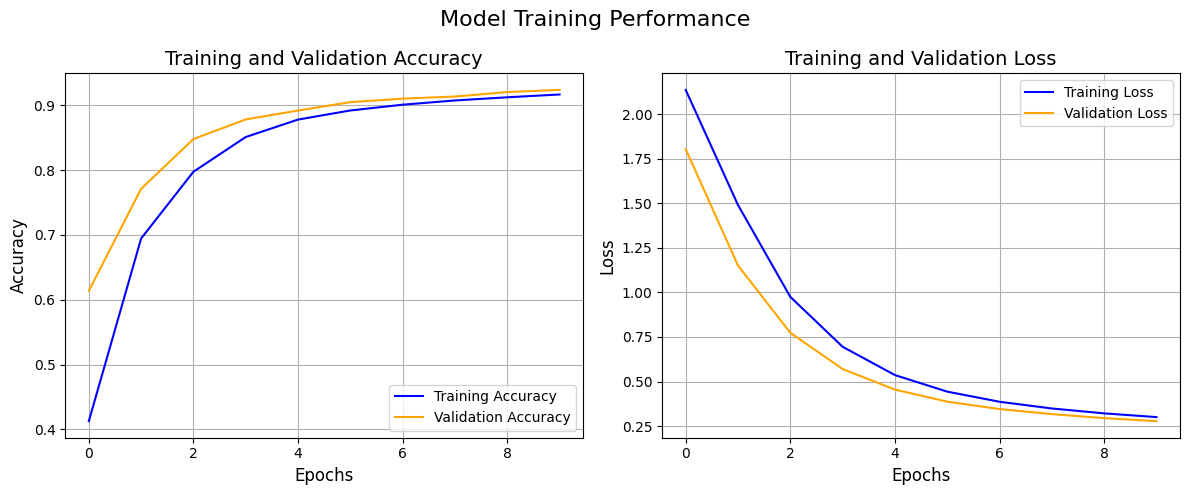

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()

Feedforward Neural Network

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy

# Load and prepare the MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Build the model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(),
              loss=SparseCategoricalCrossentropy(),
              metrics=[SparseCategoricalAccuracy()])

# Train the model
model.fit(x_train, y_train, epochs=5)

# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'\nTest accuracy: {test_acc}')

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.2615 - sparse_categorical_accuracy: 0.9251
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1150 - sparse_categorical_accuracy: 0.9661
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0794 - sparse_categorical_accuracy: 0.9761
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0584 - sparse_categorical_accuracy: 0.9818
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0458 - sparse_categorical_accuracy: 0.9858
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0802 - sparse_categorical_accuracy: 0.9755

Test accuracy: 0.9754999876022339
